# FIR Lowpass Filter Design using Ellipsoid Method

This notebook designs an FIR lowpass filter using spectral factorization method with constraint on maximum passband ripple and stopband attenuation.

**Reference:** "FIR Filter Design via Spectral Factorization and Convex Optimization" by S.-P. Wu, S. Boyd, and L. Vandenberghe

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import remez, minimum_phase, freqz, group_delay
from ellalgo.cutting_plane import Options, cutting_plane_optim
from ellalgo.ell import Ell
from ellalgo.oracles.spectral_fact import spectral_fact
from ellalgo.oracles.lowpass_oracle import create_lowpass_case

## Plotting Function

In [2]:
def plot_lowpass_result(r, Spsq_new):
    """Plot the lowpass filter design results.

    Args:
        r: Optimized autocorrelation coefficients
        Spsq_new: New stopband squared value
    """
    # frequency response of the designed filter
    h_sp = spectral_fact(r)
    h = h_sp
    print("h =", h)

    # compute the min attenuation in the stopband (convert to original vars)
    Ustop = 20 * np.log10(np.sqrt(Spsq_new))
    print("Min attenuation in the stopband is", Ustop, "dB.")

    freq = [0, 0.12, 0.2, 1.0]
    desired = [1, 0]
    h_linear = remez(151, freq, desired, fs=2.0)
    h_min_hom = minimum_phase(h_linear, method="homomorphic")

    fig = plt.figure(figsize=(10, 8))
    ax1 = fig.add_subplot(221)
    ax2 = fig.add_subplot(222)
    ax3 = fig.add_subplot(223)
    ax4 = fig.add_subplot(224)
    axs = (ax1, ax2, ax3, ax4)

    for h, style, color in zip((h_min_hom, h_sp), ("-", "-"), ("r", "k")):
        w, H = freqz(h)
        w, gd = group_delay((h, np.ones_like(h)))
        w /= np.pi
        axs[0].plot(h, color=color, linestyle=style)
        axs[1].plot(w, np.abs(H), color=color, linestyle=style)
        axs[2].plot(w, 20 * np.log10(np.abs(H)), color=color, linestyle=style)
        axs[3].plot(w, gd, color=color, linestyle=style)

    for ax in axs:
        ax.grid(True, color="0.5")
        ax.fill_between(freq[1:3], *ax.get_ylim(), color="#ffeeaa", zorder=1)

    axs[0].set(xlim=[0, len(h_linear) - 1], ylabel="Amplitude", xlabel="Samples")
    axs[1].legend(["Min-Hom", "Our"], title="Phase")
    for ax, ylim in zip(axs[1:], ([0, 1.1], [-80, 10], [-60, 60])):
        ax.set(xlim=[0, 1], ylim=ylim, xlabel="Frequency")
    axs[1].set(ylabel="Magnitude")
    axs[2].set(ylabel="Magnitude (dB)")
    axs[3].set(ylabel="Group delay")
    plt.tight_layout()
    plt.show()

## Optimization using Ellipsoid Method

Optimized coefficients r: [ 1.40938042e-01  1.36250026e-01  1.22774382e-01  1.02163891e-01
  7.68949418e-02  4.98926089e-02  2.41033333e-02  2.08263960e-03
 -1.43348611e-02 -2.42335175e-02 -2.76601779e-02 -2.55146960e-02
 -1.93204769e-02 -1.09203944e-02 -2.15809109e-03  5.40342364e-03
  1.06805781e-02  1.31647447e-02  1.29092832e-02  1.04254859e-02
  6.51889697e-03  2.10216690e-03 -1.98008589e-03 -5.08358447e-03
 -6.84004107e-03 -7.17062719e-03 -6.24699839e-03 -4.41509819e-03
 -2.10383162e-03  2.63301402e-04  2.33751279e-03  3.88674721e-03
  4.80794470e-03  5.11490172e-03  4.90808744e-03  4.33698163e-03
  3.56390259e-03  2.73438576e-03  1.95892663e-03  1.30614041e-03
  8.04751508e-04  4.52526680e-04  2.27325728e-04  9.79018184e-05
  3.29114213e-05  6.08956576e-06 -1.72370364e-06 -2.10055016e-06]
h = [ 0.00429413  0.00947463  0.01882742  0.03202705  0.04928573  0.06956475
  0.09107199  0.11159122  0.12815355  0.13809741  0.13906697  0.12998256
  0.11094379  0.08371499  0.05108801  0.017

C:\Users\luk03\AppData\Local\Temp\ipykernel_27008\3879688136.py:31: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w, gd = group_delay((h, np.ones_like(h)))
C:\Users\luk03\AppData\Local\Temp\ipykernel_27008\3879688136.py:31: UserWarning: The filter's denominator is extremely small at frequencies [0.785, 1.178, 1.571, 1.963, 2.356, 2.749], around which a singularity may be present
  w, gd = group_delay((h, np.ones_like(h)))


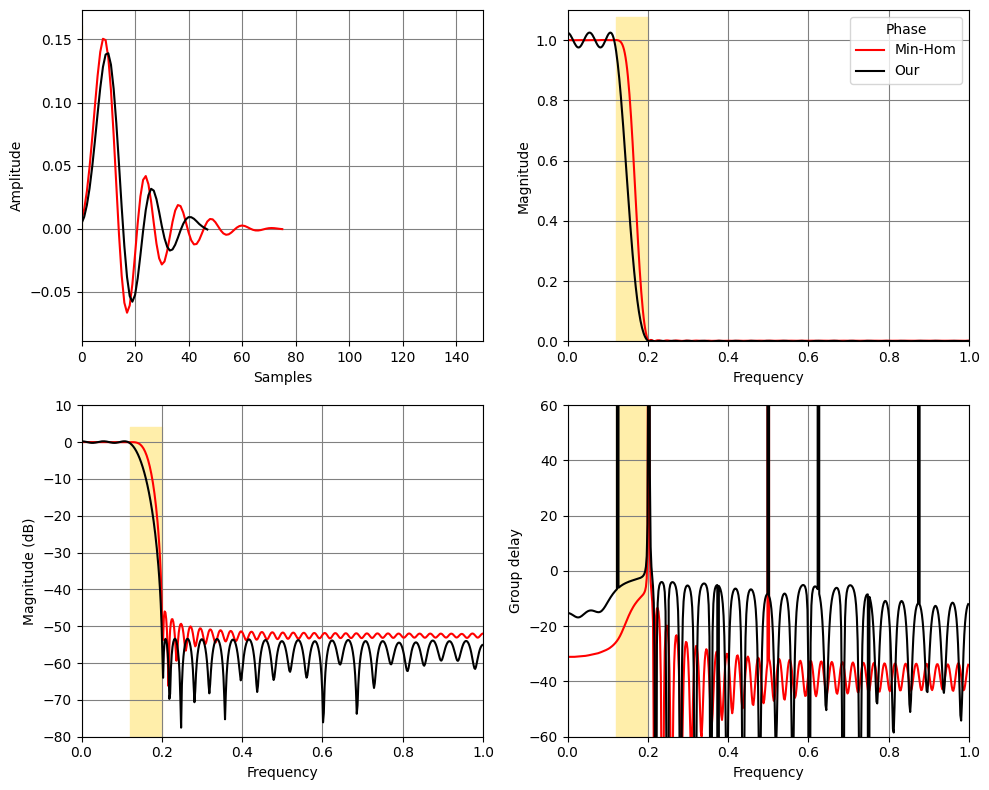

In [3]:
if __name__ == "__main__":
    ndim = 48
    r0 = np.zeros(ndim)  # initial x0
    r0[0] = 0

    # Initialize ellipsoid (sphere)
    E = Ell(40.0, r0)

    # Create lowpass problem
    P = create_lowpass_case(ndim)
    Spsq = P.sp_sq

    options = Options()

    # Run cutting plane optimization
    r, Spsq_new, _ = cutting_plane_optim(P, E, Spsq, options)

    assert r is not None
    print("Optimized coefficients r:", r)

    # Plot results
    plot_lowpass_result(r, Spsq_new)